In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
import os

In [2]:
# ==========================================
# 1. CONFIGURATION & PATHS
# ==========================================
# Assuming this script is running inside the 'scripts/' folder
BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.path.abspath('..')
TRAIN_DIR = os.path.join(BASE_DIR, 'dataset', 'train')
VAL_DIR = os.path.join(BASE_DIR, 'dataset', 'value')
MODEL_SAVE_PATH = os.path.join(BASE_DIR, 'models', 'kiosk_face_model_eff.keras')

BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)
EPOCHS = 10

In [3]:
# Ensure the models directory exists
os.makedirs(os.path.dirname(MODEL_SAVE_PATH), exist_ok=True)

In [4]:
# ==========================================
# 2. DATA LOADING
# ==========================================
print("Loading training dataset...")
train_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    TRAIN_DIR,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE
)

print("Loading validation dataset...")
val_dataset = tf.keras.preprocessing.image_dataset_from_directory(
    VAL_DIR,
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=IMAGE_SIZE
)

# Extract class names dynamically from folder names
class_names = train_dataset.class_names
NUM_CLASSES = len(class_names)
print(f"Detected {NUM_CLASSES} classes: {class_names}")

# Optimize dataset loading for performance
AUTOTUNE = tf.data.AUTOTUNE
train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.prefetch(buffer_size=AUTOTUNE)

Loading training dataset...
Found 1200 files belonging to 15 classes.
Loading validation dataset...
Found 300 files belonging to 15 classes.
Detected 15 classes: ['elef', 'jose', 'jp', 'len', 'lenel', 'mich', 'nang_anton', 'nang_sheena', 'nel', 'nong_josh', 'rofer', 'siaotungz', 'sir_ng', 'wends', 'wiegard']


In [5]:
# ==========================================
# 3. ARCHITECTURE DESIGN (Transfer Learning)
# ==========================================
# Data Augmentation Layer to prevent overfitting
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
], name="data_augmentation")

# Load MobileNetV2 without the final classification layers
print("Loading EfficientNetV2B0 backbone...")
base_model = tf.keras.applications.EfficientNetV2B0(
    input_shape=IMAGE_SIZE + (3,),
    include_top=False,
    weights='imagenet'
)

# Freeze the base model so its pre-trained weights aren't destroyed
base_model.trainable = False

# Construct the custom model
inputs = tf.keras.Input(shape=IMAGE_SIZE + (3,))
x = data_augmentation(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x) # 30% Dropout to further prevent overfitting
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

# Compile the model (Manual definition required by rubric)
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Loading EfficientNetV2B0 backbone...


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 15)             │        19,215 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,938,527 (22.65 MB)

 Trainable params: 19,215 (75.06 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [6]:
# ==========================================
# 4. TRAINING THE MODEL
# ==========================================
print("\nStarting Training...")
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS
)


Starting Training...
Epoch 1/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 12s 233ms/step - accuracy: 0.4517 - loss: 2.0694 - val_accuracy: 0.7500 - val_loss: 1.5096
Epoch 2/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 221ms/step - accuracy: 0.8717 - loss: 1.0323 - val_accuracy: 0.8967 - val_loss: 0.9349
Epoch 3/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 221ms/step - accuracy: 0.9325 - loss: 0.6240 - val_accuracy: 0.9233 - val_loss: 0.6696
Epoch 4/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 222ms/step - accuracy: 0.9350 - loss: 0.4643 - val_accuracy: 0.9300 - val_loss: 0.5247
Epoch 5/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 223ms/step - accuracy: 0.9550 - loss: 0.3633 - val_accuracy: 0.9533 - val_loss: 0.4365
Epoch 6/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 232ms/step - accuracy: 0.9608 - loss: 0.2938 - val_accuracy: 0.9233 - val_loss: 0.3875
Epoch 7/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 8s 222ms/step - accuracy: 0.9592 - loss: 0.2609 - val_accuracy: 0.9400 - val_loss: 0.3409
Epoch 8/10
38/38 ━━━━━━━━━━━━━━━━━━━━ 9s 229ms/step - accuracy: 0.9633 - loss: 0.

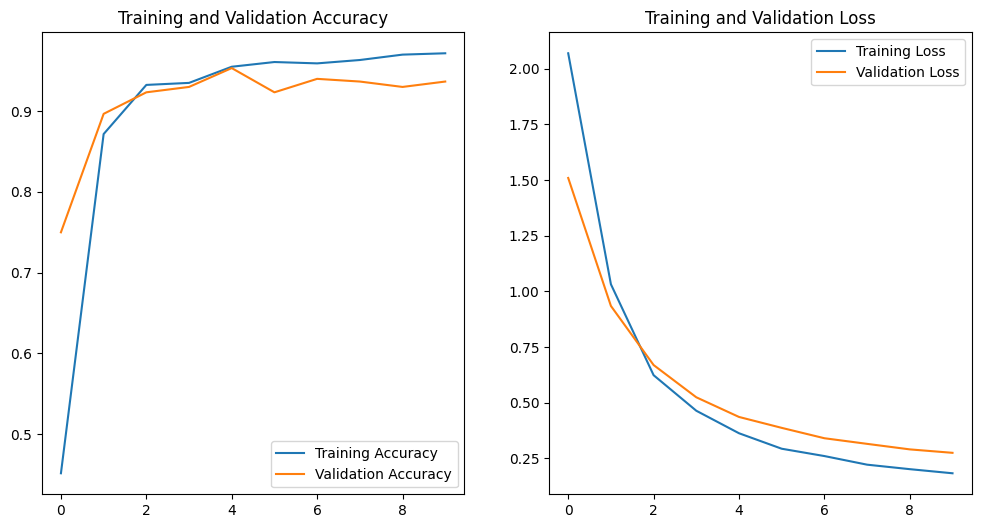

In [7]:
# ==========================================
# 5. MODEL PERFORMANCE EVALUATION (Plotting)
# ==========================================
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show() # Display the graphs to prove avoidance of overfitting

In [8]:
# ==========================================
# 6. SAVING THE FINAL DELIVERABLE
# ==========================================
model.save(MODEL_SAVE_PATH)
print(f"\n✅ Training complete! Model successfully saved to: {MODEL_SAVE_PATH}")
print(f"Class mapping: {dict(enumerate(class_names))}")


✅ Training complete! Model successfully saved to: /Users/cxnner05/Documents/projects/ml-finals/backend/models/kiosk_face_model_eff.keras
Class mapping: {0: 'elef', 1: 'jose', 2: 'jp', 3: 'len', 4: 'lenel', 5: 'mich', 6: 'nang_anton', 7: 'nang_sheena', 8: 'nel', 9: 'nong_josh', 10: 'rofer', 11: 'siaotungz', 12: 'sir_ng', 13: 'wends', 14: 'wiegard'}
